# Analisi delle transazioni di betting SatoshiDice

Questo notebook presenta la relazione del progetto su SatoshiDice. Il codice completo della pipeline si trova nei moduli Python in `src/` e negli script eseguibili in `scripts/`.

In [64]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

PROCESSED_DIR = Path("outputs/processed")
FIGURES_DIR = Path("outputs/figures")

## 1. Introduzione

SatoshiDice è stato uno dei servizi di gambling più popolari sulla blockchain Bitcoin. Gli utenti piazzavano una puntata inviando una transazione Bitcoin verso uno specifico indirizzo SatoshiDice, associato a una certa condizione di vincita.

L'obiettivo del progetto è identificare le transazioni di betting verso SatoshiDice e analizzarne il comportamento nel tempo, la popolarità degli indirizzi, i payout, i pattern dei top address e le catene di simple bet.

### Dataset utilizzati

I dataset principali sono file CSV senza header. I nomi delle colonne vengono quindi assegnati manualmente nei loader in `src/load_data.py`.

| Dataset | Ruolo | Colonne principali |
|---|---|---|
| `transactions.csv` | metadati delle transazioni | `timestamp`, `blockId`, `txId`, `isCoinbase`, `fee` |
| `outputs.csv` | output delle transazioni | `txId`, `position`, `addressId`, `amount` |
| `inputs.csv` | input delle transazioni | `txId`, `prevTxId`, `prevTxpos` |
| `mapping.csv` | mapping indirizzi Bitcoin | `hash`, `addressId` |
| `satoshiDiceInfos.tsv` | lista indirizzi SatoshiDice | address, odds, multiplier e metadati del gioco |

Gli importi e le fee sono espressi in satoshi e vengono convertiti in BTC usando `100,000,000` satoshi per BTC. Le transazioni coinbase vengono escluse quando si identificano le bet, perché non rappresentano transazioni generate da utenti.

## 2. Overview della pipeline

La pipeline è stata organizzata in moduli Python riutilizzabili e script di build. Gli output intermedi sono salvati in `outputs/processed/`, mentre le figure sono salvate in `outputs/figures/`.

```text
raw blockchain datasets
        ↓
mapping degli indirizzi SatoshiDice
        ↓
identificazione output verso SatoshiDice
        ↓
costruzione bet_transactions.csv.gz
        ↓
analisi temporali, popolarità, payout e top address
        ↓
simple-bet chains e validazione con WalletExplorer
```

Nel notebook non vengono rieseguiti i build completi sui dataset raw.

## 3. Identificazione delle bet

Una transazione di betting viene identificata cercando output diretti verso indirizzi SatoshiDice noti. Dopo aver mappato gli indirizzi testuali al relativo `addressId`, la tabella `outputs.csv` viene unita alla lista degli address SatoshiDice.

```python
bet_outputs = outputs.merge(
    known_satoshi_addresses,
    on="addressId",
    how="inner",
)
```

Successivamente vengono aggiunti i metadati della transazione tramite `txId`, come timestamp, blocco e fee.

In [65]:
with open(PROCESSED_DIR / "identification_report.json") as f:
    identification_report = json.load(f)

pd.DataFrame([identification_report])

,total_transactions,coinbase_transactions,non_coinbase_transactions,satoshi_bet_outputs,bet_transactions
0,10572829,214563,10358266,2363985,1965817


Sono state identificate `1,965,817` transazioni di betting non-coinbase.

Il numero di output verso SatoshiDice è più alto del numero di transazioni uniche, perché una stessa transazione può contenere più output.

## 4. Analisi

### 4.1 Percentuale di transazioni SatoshiDice nel tempo

La prima analisi misura quanto SatoshiDice incide sul totale delle transazioni Bitcoin nel tempo.

Il denominatore è il numero totale di transazioni Bitcoin, mentre il numeratore è il numero di transazioni SatoshiDice uniche.

In [66]:
monthly = pd.read_csv(PROCESSED_DIR / "bet_percentage_by_month.csv")
monthly.head()

,period,total_transactions,bet_transactions,bet_percentage
0,2009-01,2576,0,0.0
1,2009-02,3417,0,0.0
2,2009-03,3487,0,0.0
3,2009-04,3459,0,0.0
4,2009-05,3401,0,0.0


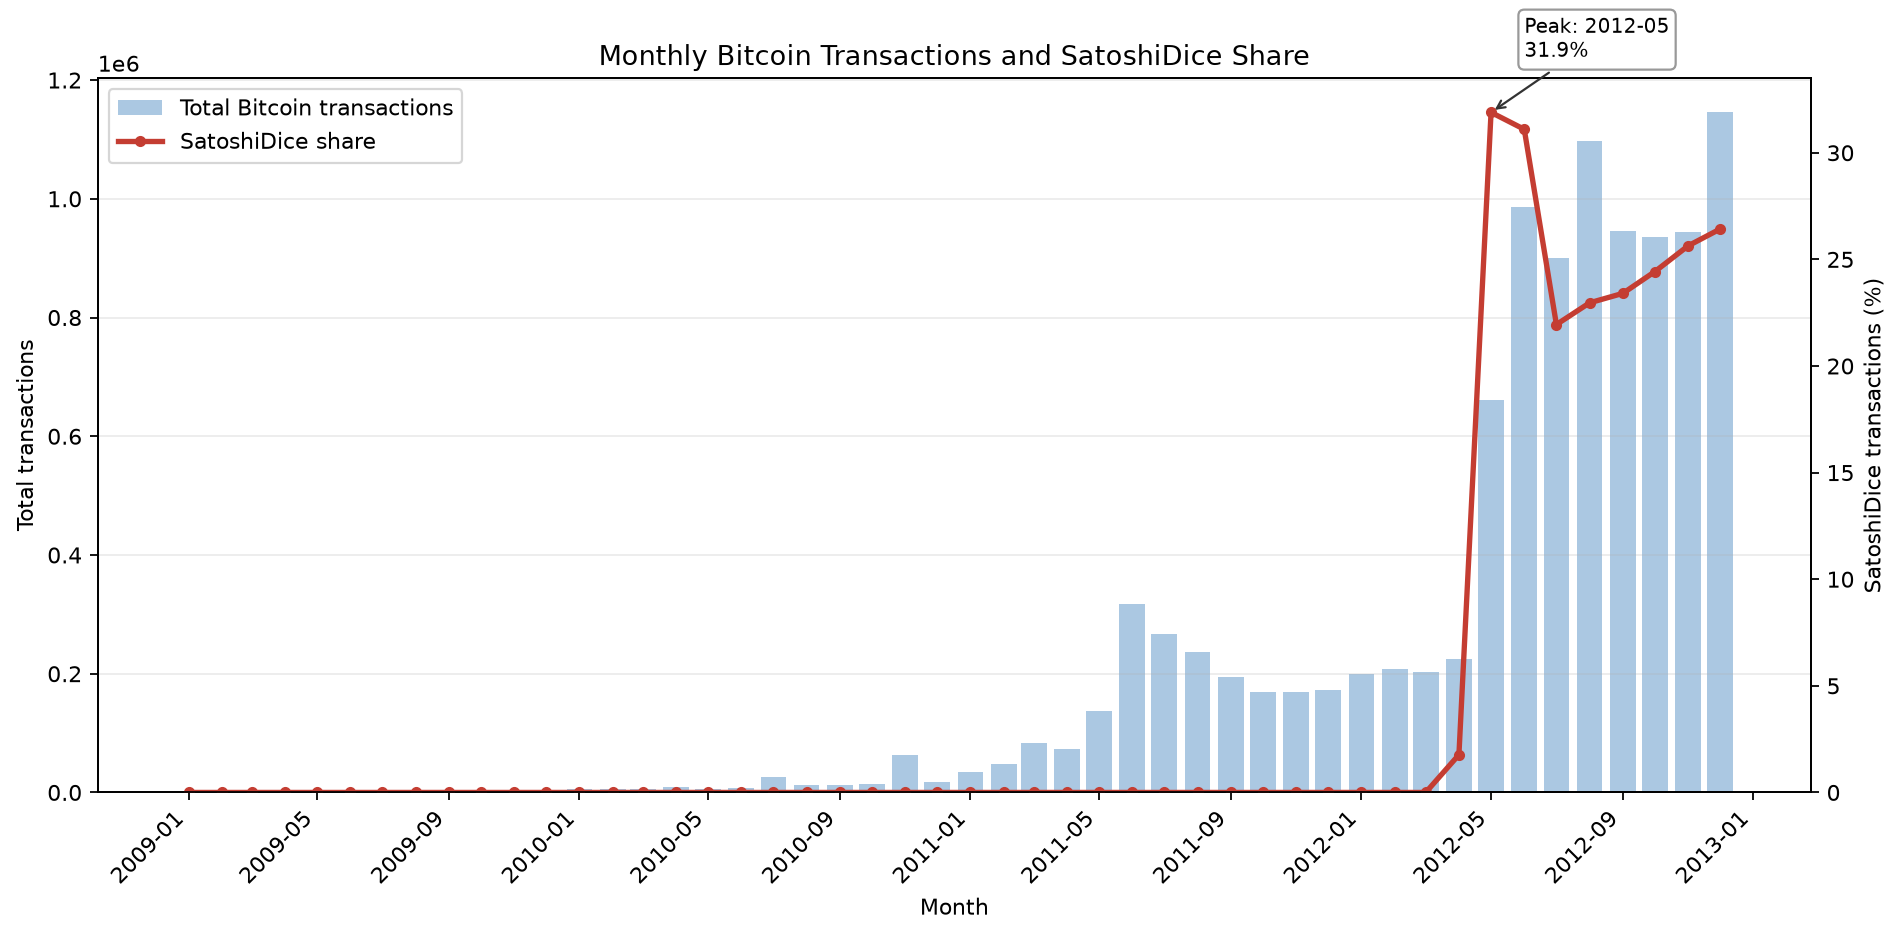

In [67]:
display(Image(FIGURES_DIR / "monthly_transactions_vs_satoshidice_share.png"))

Il grafico mostra che, nel periodo di maggiore attività, SatoshiDice rappresentava una quota rilevante delle transazioni Bitcoin.

La piattaforma di gambling viene lanciata ad Aprile 2012, punto in cui inizia la crescita osservabile nel grafico, raggiungendo rapidamente ampia popolarità nella rete Bitcoin, raggiungendo un picco di dominance del 31.9% rispetto alle transazioni blockchain mensili

### 4.2 Popolarità degli indirizzi SatoshiDice

Ogni indirizzo SatoshiDice corrisponde a una diversa condizione di gioco. La popolarità viene misurata in due modi:

- numero di transazioni di betting uniche;
- totale BTC inviati all'indirizzo.

Il conteggio delle bet usa `txId.nunique()` per evitare di contare più volte la stessa transazione quando i dati sono a granularità output.

In [42]:
address_popularity = pd.read_csv(PROCESSED_DIR / "address_popularity.csv")
address_popularity.sort_values("bet_count", ascending=False).head(10)

,addressId,satoshiAddress,diceName,bet_count,total_bet_amount_btc
26,3524394,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,lessthan 32000,810212,528711.495882
25,3517636,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206,371764.273003
24,3517367,1dice9wcMu5hLF4g81u8nioL5mmSHTApw,lessthan 48000,235719,244574.310855
23,3534212,1dice7fUkz5h4z2wPc1wLMPWgB5mDwKDx,lessthan 16000,154832,147341.360437
22,3525822,1dice6YgEVBf88erBFra9BHf6ZMoyvG88,lessthan 8000,130621,45925.441348
21,3524243,1dice7W2AicHosf5EL3GFDUVga7TgtPFn,lessthan 24000,125197,144823.539073
20,3526385,1dice5wwEZT2u6ESAdUGG6MHgCpbQqZiy,lessthan 1000,72019,17856.640702
19,3525858,1dice1e6pdhLzzWQq7yMidf6j8eAg7pkY,lessthan 1,60417,570.572846
18,3535501,1dice7EYzJag7SxkdKXLr8Jn14WUb3Cf1,lessthan 12000,48532,67512.172691
17,3517234,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN,lessthan 2000,42163,17489.329630


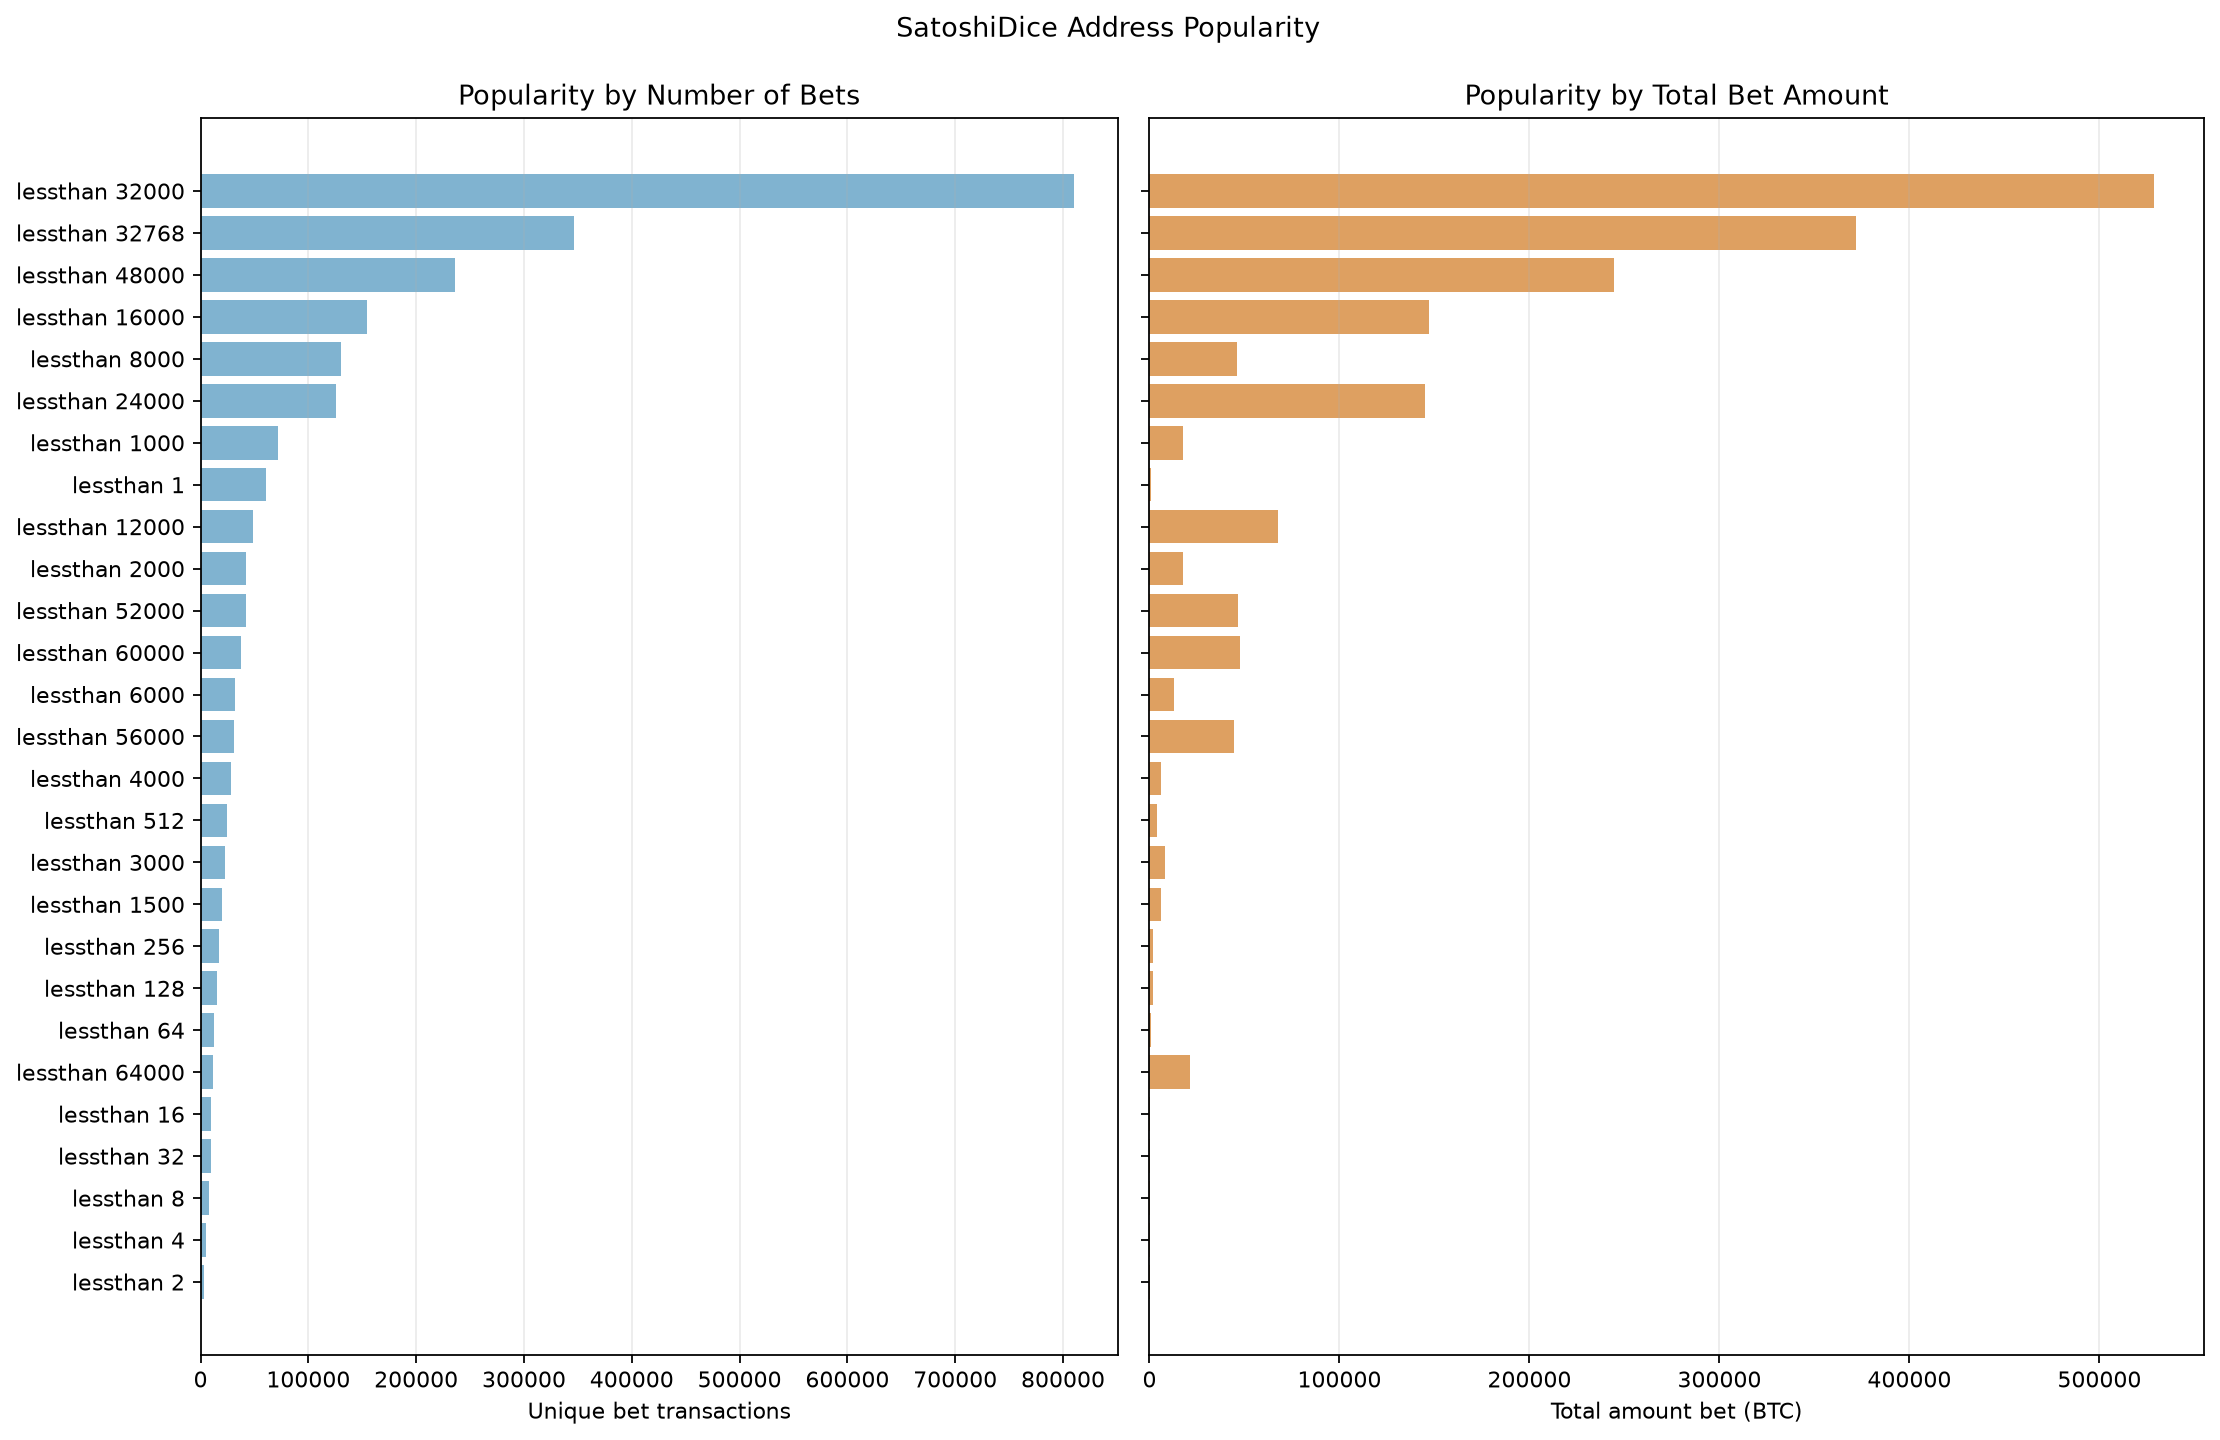

In [43]:
display(Image(FIGURES_DIR / "address_popularity_comparison.png"))

Gli indirizzi più popolari per numero di bet non coincidono necessariamente con quelli più importanti per quantità totale di BTC.

Questa distinzione è utile perché molte puntate piccole e poche puntate grandi rappresentano comportamenti diversi degli utenti.
Un esempio rilevante é l'address "lessthan 8000", che é popolare in quanto a numero di bets, ma non in quanto ad amount: giocatori che scommettono elevate quantità di BTC tenderanno a scommettere su address che hanno una ragionevole probabilità di vincita.

### 4.3 Matching dei payout e distanza in blocchi

I payout vengono identificati seguendo la relazione UTXO. Se un input successivo spende un output di bet verso SatoshiDice, quella transazione successiva viene interpretata come payout.

Idea centrale del matching:

```text
inputs.prevTxId / inputs.prevTxpos
        ↓
bet_transactions.txId / bet_transactions.position
```

La distanza viene misurata in blocchi, non in tempo, perché i timestamp dei blocchi Bitcoin sono dichiarati dai miner e possono essere meno affidabili per misure temporali precise.

In [44]:
payout_summary = pd.read_csv(PROCESSED_DIR / "payout_distance_summary.csv")
payout_summary

,total_bet_transactions,bet_transactions_with_payout,bet_transactions_with_payout_percentage,payout_transactions,payout_links,block_distance_mean,block_distance_median,block_distance_p75,block_distance_p90,block_distance_p95
0,1965817,1965206,99.968919,2349938,2349938,1.251346,0.0,0.0,1.0,3.0


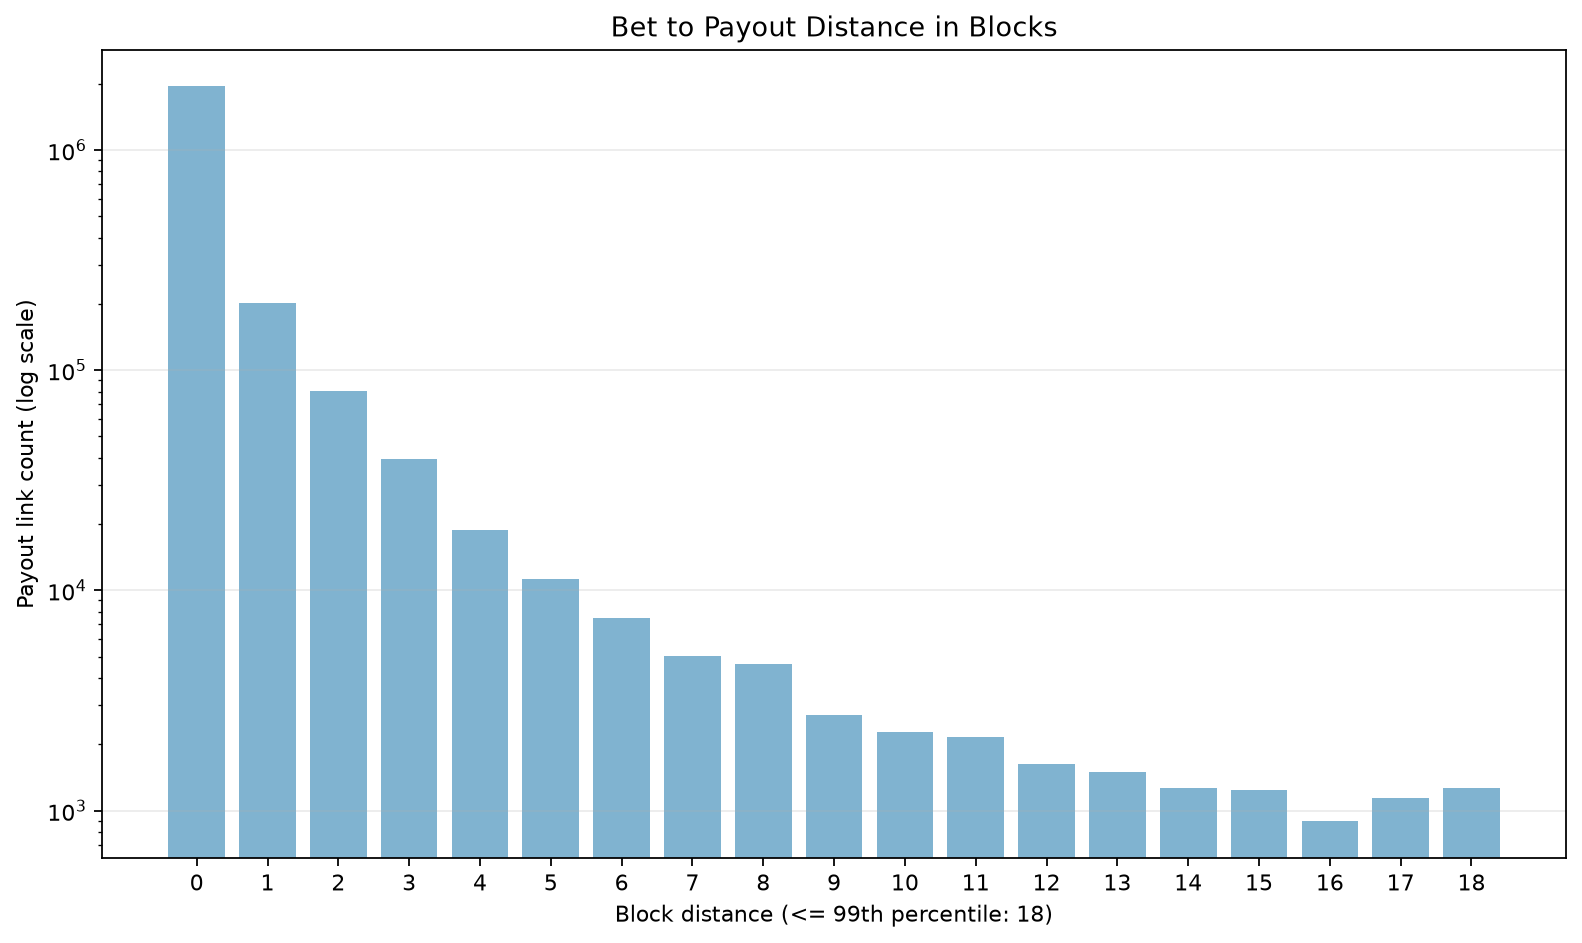

In [45]:
display(Image(FIGURES_DIR / "payout_distance_blocks.png"))

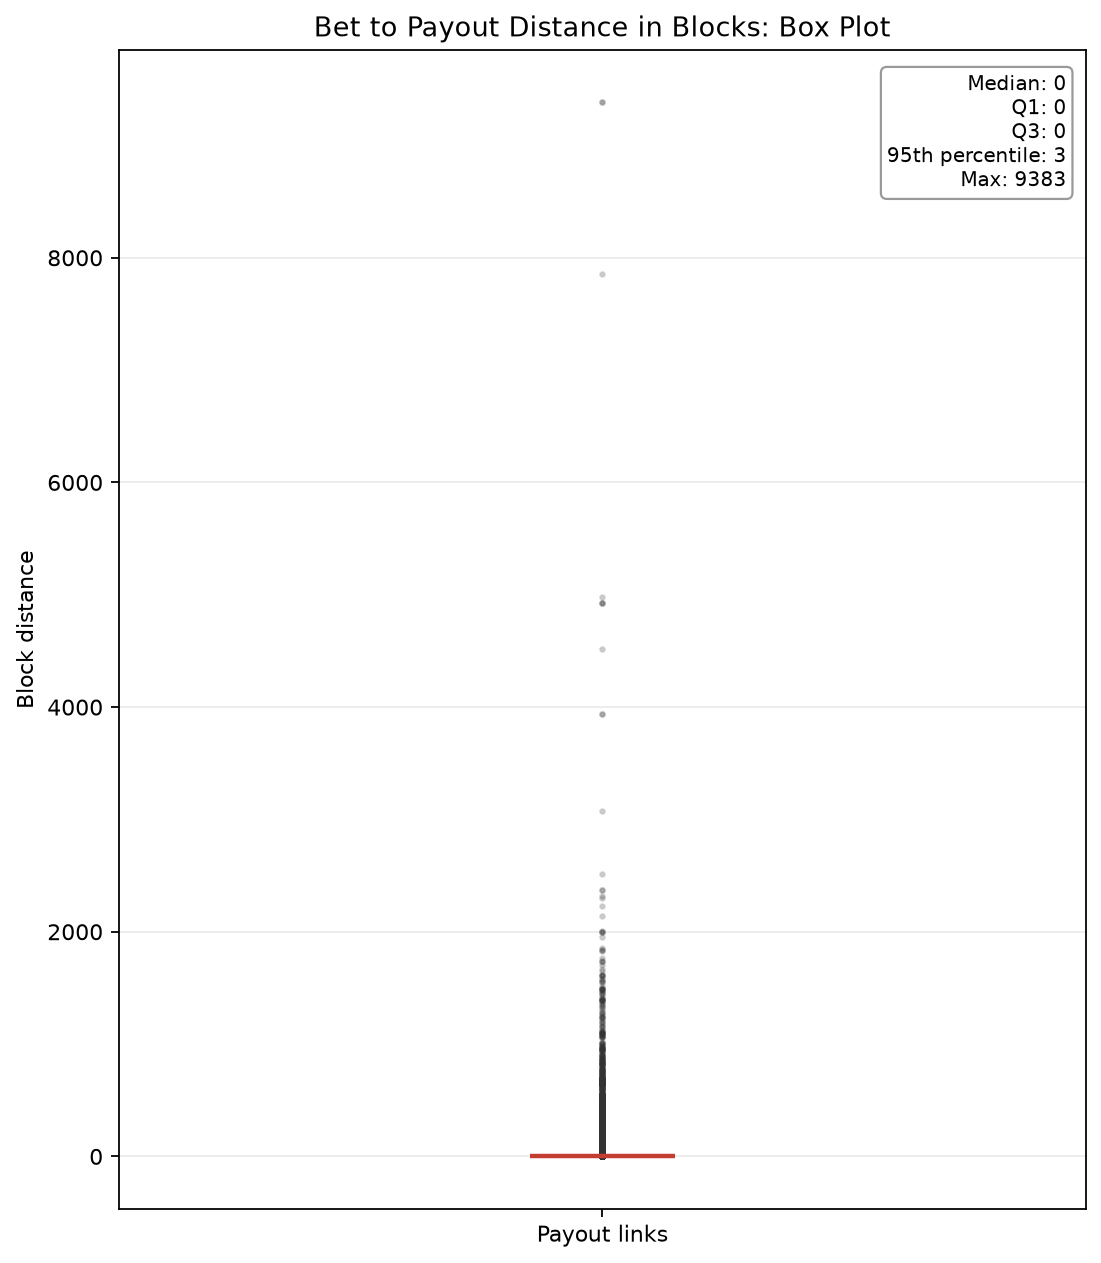

In [46]:
display(Image(FIGURES_DIR / "payout_distance_blocks_boxplot.png", width=700))

La maggior parte dei payout individuati avviene molto rapidamente. La mediana della distanza in blocchi è `0`, quindi almeno metà dei payout matchati avviene nello stesso blocco della bet.

La media è più alta della mediana perché la distribuzione è asimmetrica: pochi payout più ritardati aumentano il valore medio. Il box plot aiuta a vedere sia la concentrazione su zero sia gli outlier secondo la regola standard `1.5 * IQR`.

Una distanza in blocchi pari a zero non significa che il payout sia avvenuto prima della conferma della bet. Significa che la bet e la transazione che spende il suo output verso SatoshiDice sono state incluse nello stesso blocco. Questo è possibile perché SatoshiDice poteva osservare la bet non confermata nella mempool e trasmettere una transazione figlia che spendeva quell'output. Se un miner include entrambe nello stesso blocco, nell'ordine corretto, la distanza misurata è zero.

### 4.4 Analisi dei top 3 indirizzi SatoshiDice

Per analizzare il comportamento degli indirizzi più rilevanti, sono stati selezionati i tre indirizzi SatoshiDice con il maggior numero di transazioni di betting uniche.

#### 4.4.1 Distribuzione temporale delle bet

Le transazioni dei top 3 indirizzi vengono raggruppate per ora, giorno e settimana. Questo permette di osservare se l'attività è distribuita in modo regolare o concentrata in specifici periodi.

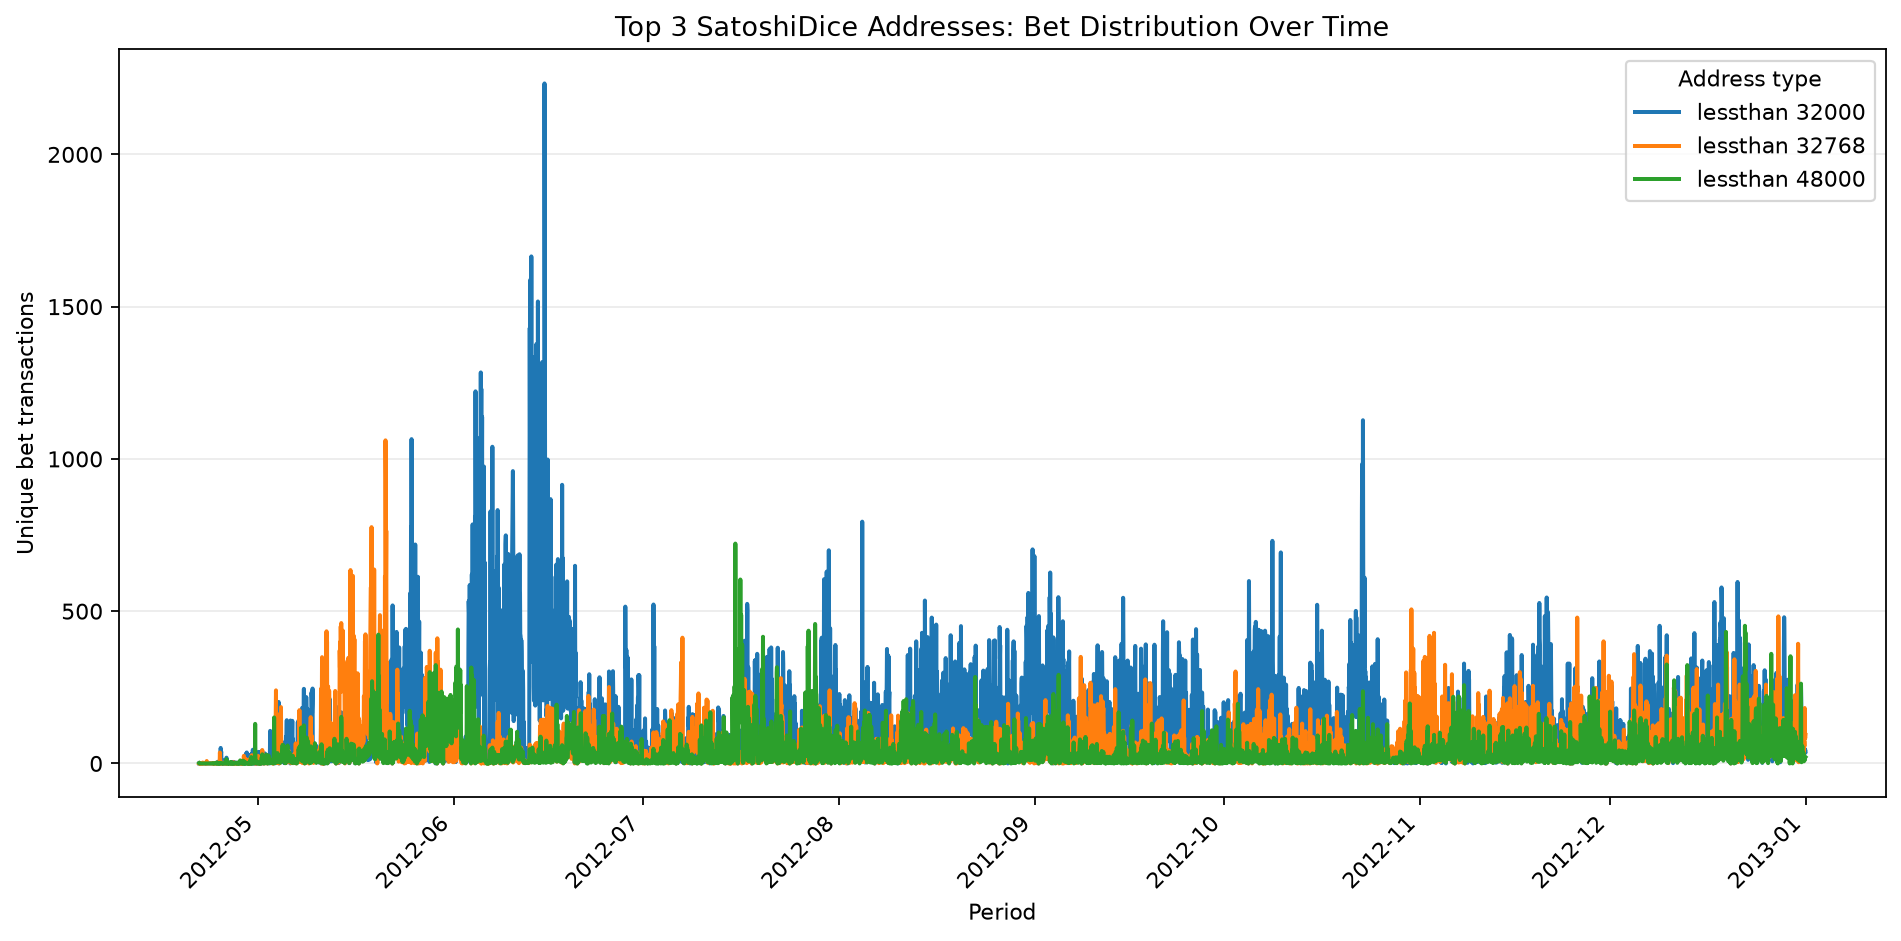

In [47]:
display(Image(FIGURES_DIR / "top3_bet_distribution_by_hour.png"))

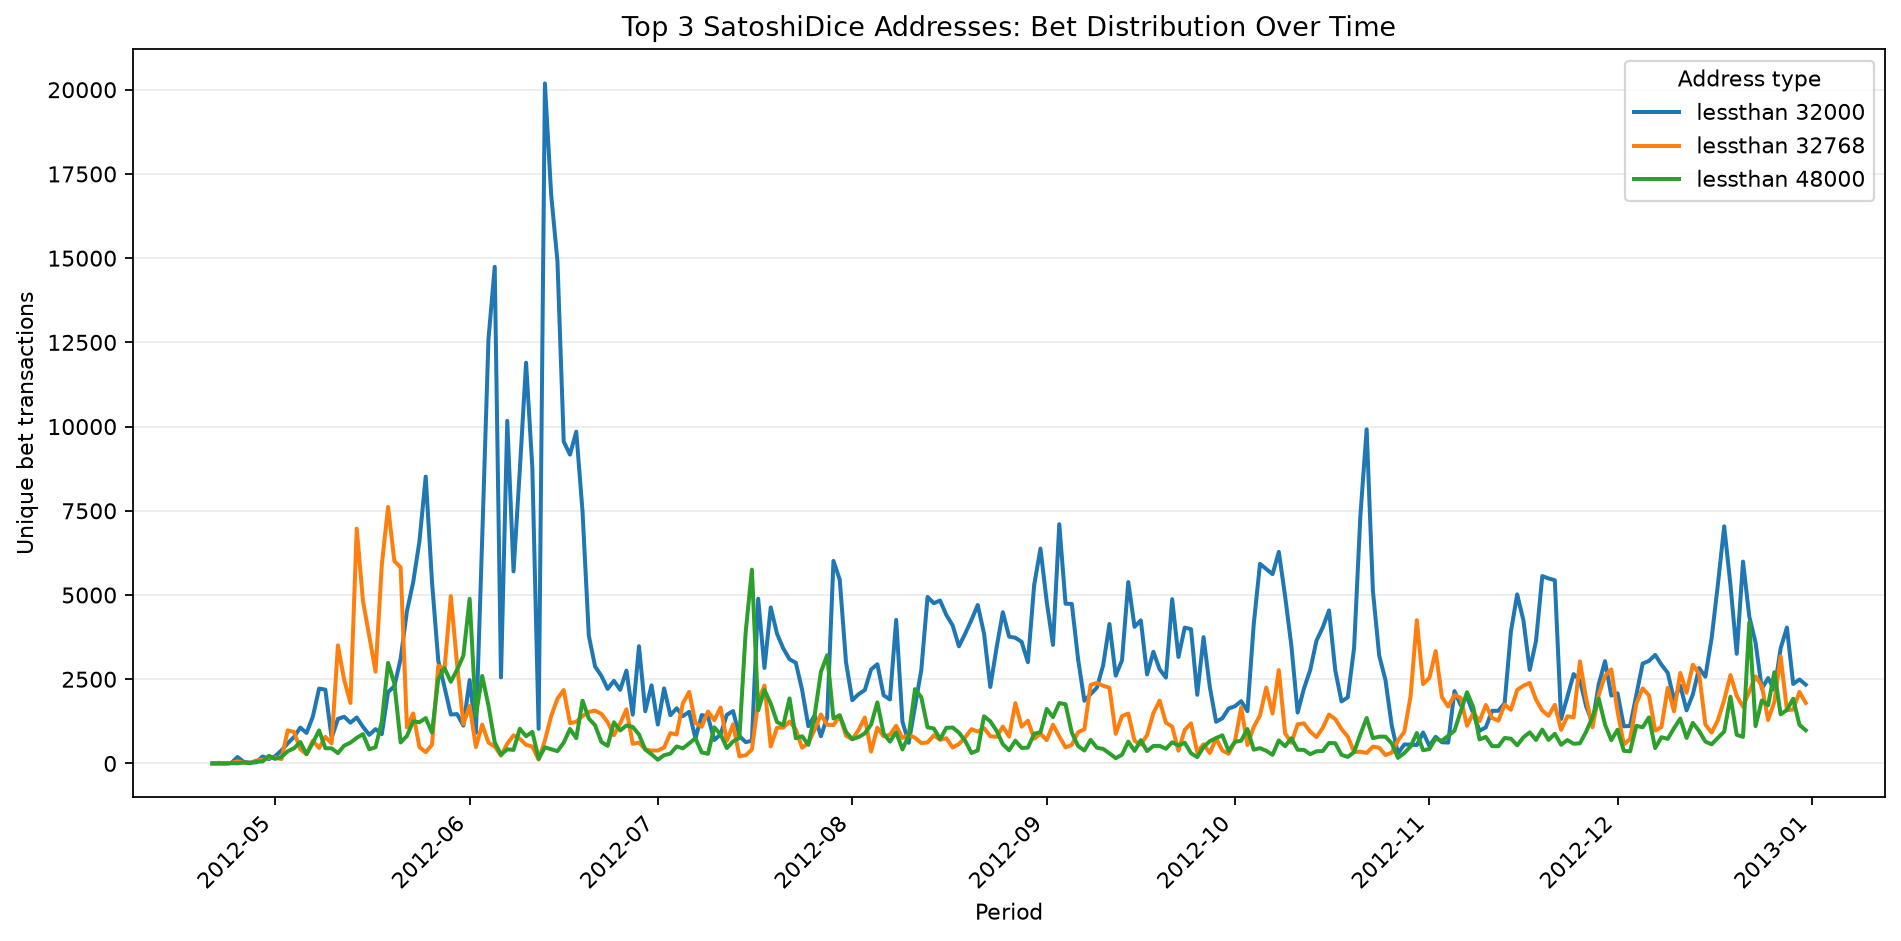

In [48]:
display(Image(FIGURES_DIR / "top3_bet_distribution_by_day.png"))

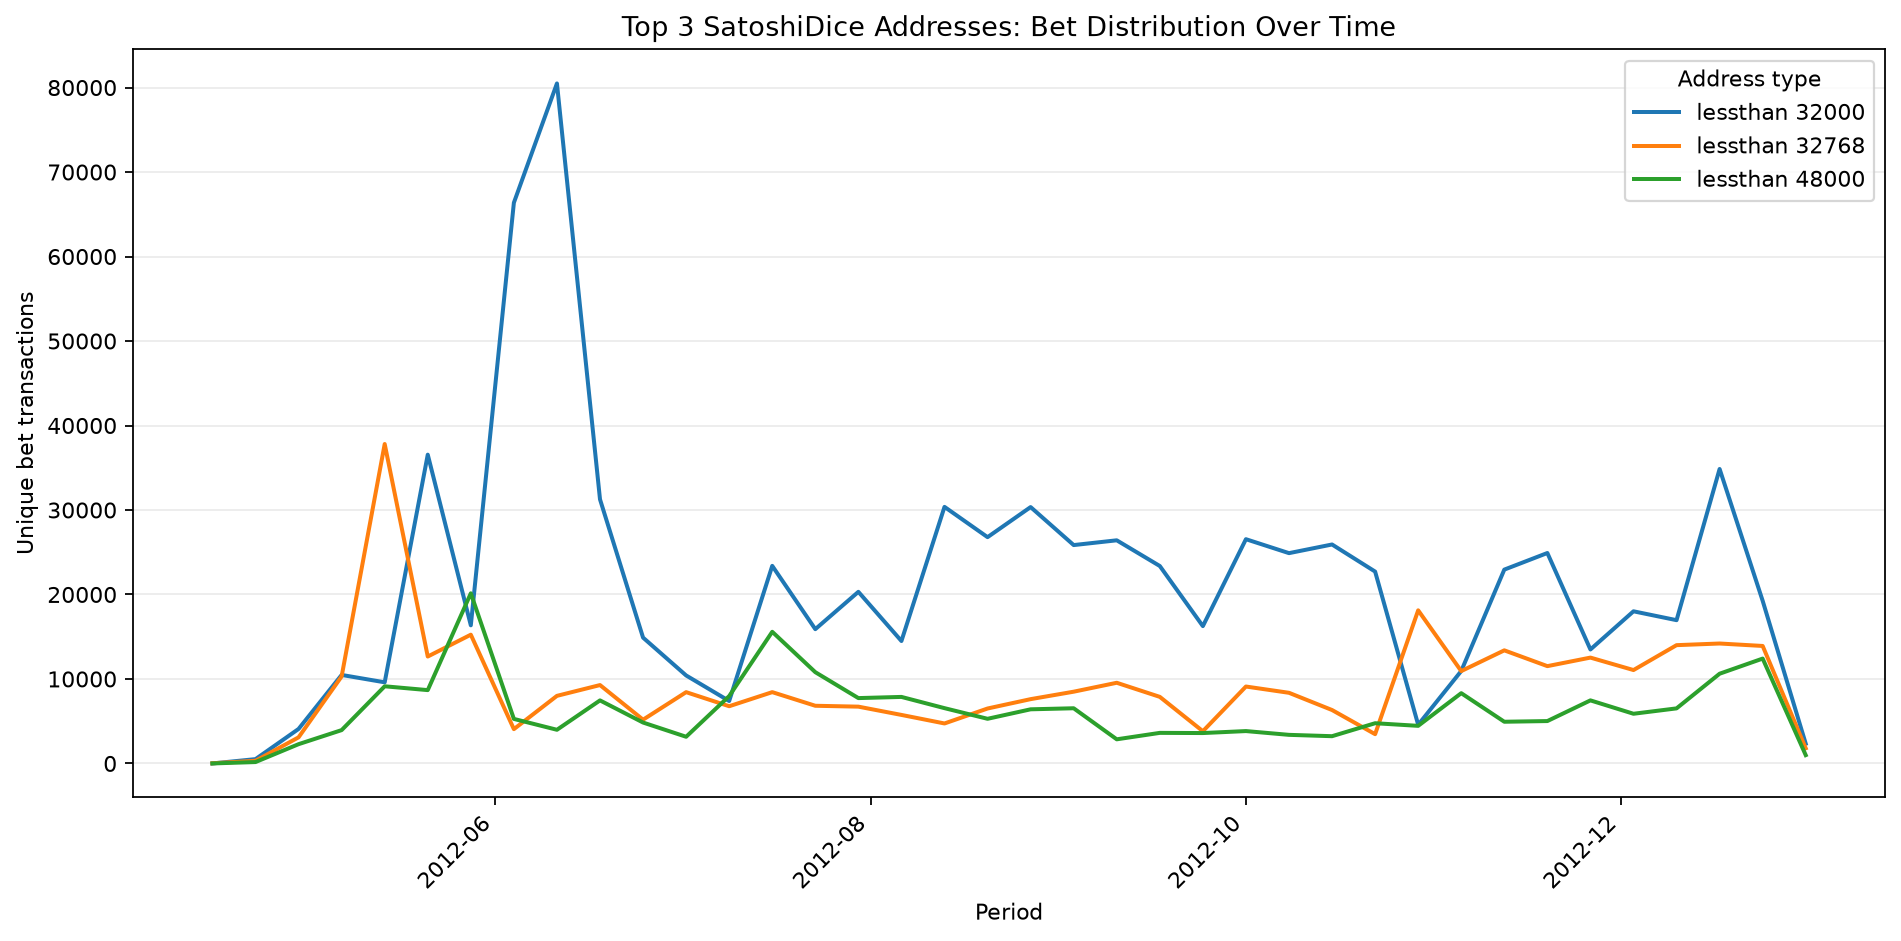

In [49]:
display(Image(FIGURES_DIR / "top3_bet_distribution_by_week.png"))

I top address mostrano periodi di forte attività alternati a periodi meno intensi. L'attività non è quindi perfettamente uniforme, ma tende a concentrarsi in finestre temporali specifiche.

#### 4.4.2 Relazione tra fee e importo della bet

Questa analisi verifica se le transazioni con bet più alte tendono ad avere fee più alte. La relazione viene valutata tramite correlazione e visualizzata con uno scatter plot.

In [68]:
fee_amount_summary = pd.read_csv(PROCESSED_DIR / "top3_fee_amount_correlation.csv")
fee_amount_summary

,scope,addressId,diceName,n_bets,n_positive_fee_bets,pearson_fee_amount,spearman_fee_amount,pearson_positive_fee_amount,spearman_positive_fee_amount,median_fee_btc,median_bet_amount_btc
0,all_top3,NaN,NaN,1392137,1364877,0.004564,0.105587,0.006688,0.163831,0.0005,0.050
1,address,3517367.0,lessthan 48000,235719,229809,0.004430,0.086798,0.005511,0.138571,0.0005,0.100
2,address,3517636.0,lessthan 32768,346206,337590,0.002306,0.153309,0.004653,0.224321,0.0005,0.056
3,address,3524394.0,lessthan 32000,810212,797478,0.011607,0.078155,0.016995,0.131608,0.0005,0.040


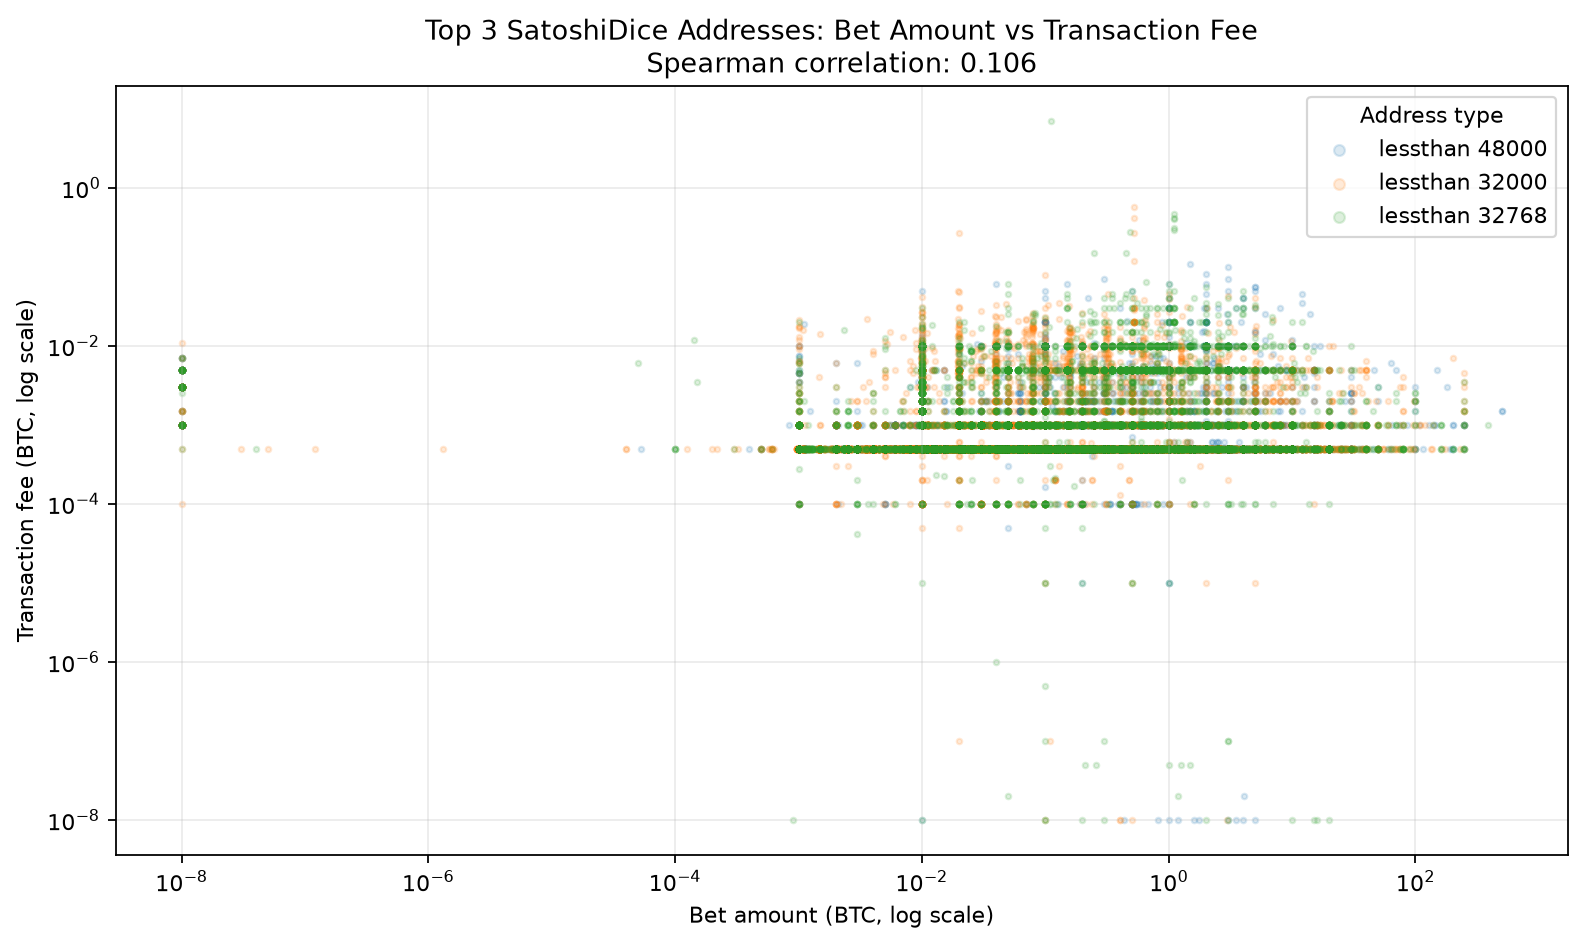

In [69]:
display(Image(FIGURES_DIR / "top3_fee_amount_correlation.png"))

La correlazione tra importo della bet e fee è molto debole. Questo risultato è coerente con il funzionamento di Bitcoin: la fee riguarda l'inclusione della transazione nella blockchain, non il meccanismo di gioco di SatoshiDice.

Per la visualizzazione vengono mostrati solo i punti con fee positiva, perché `log(0)` non è definito. I coefficienti di correlazione restano calcolati sull'intero dataset.

Ad un livello più intuitivo, potremmo aspettarci invece che le fee siano correlate ad altri parametri come:
- la dimensione in byte stimata della transazione
- quanto è congestionata la rete
- quanto velocemente l'utente vuole confermare la transazione (che non si traduce in chance di vittoria maggiori nella bet)

#### 4.4.3 Intervallo tra bet consecutive

Per ogni top address, le bet vengono ordinate per timestamp. L'intervallo è calcolato come differenza tra il timestamp di una bet e quello della bet precedente dello stesso indirizzo.

Idea centrale del codice:

```python
grouped = filtered.groupby("addressId")
previous_timestamp = grouped["timestamp"].shift()
filtered["timeIntervalSeconds"] = filtered["timestamp"] - previous_timestamp
```

In [52]:
interval_summary = pd.read_csv(PROCESSED_DIR / "top3_bet_interval_summary.csv")
interval_summary

,addressId,diceName,n_intervals,time_interval_minutes_mean,time_interval_minutes_median,time_interval_minutes_p75,time_interval_minutes_p90,time_interval_minutes_p95
0,3517367,lessthan 48000,235718,1.553313,0.0,0.0,0.0,10.283333
1,3517636,lessthan 32768,346205,1.057455,0.0,0.0,0.0,4.933333
2,3524394,lessthan 32000,810211,0.450068,0.0,0.0,0.0,0.000000


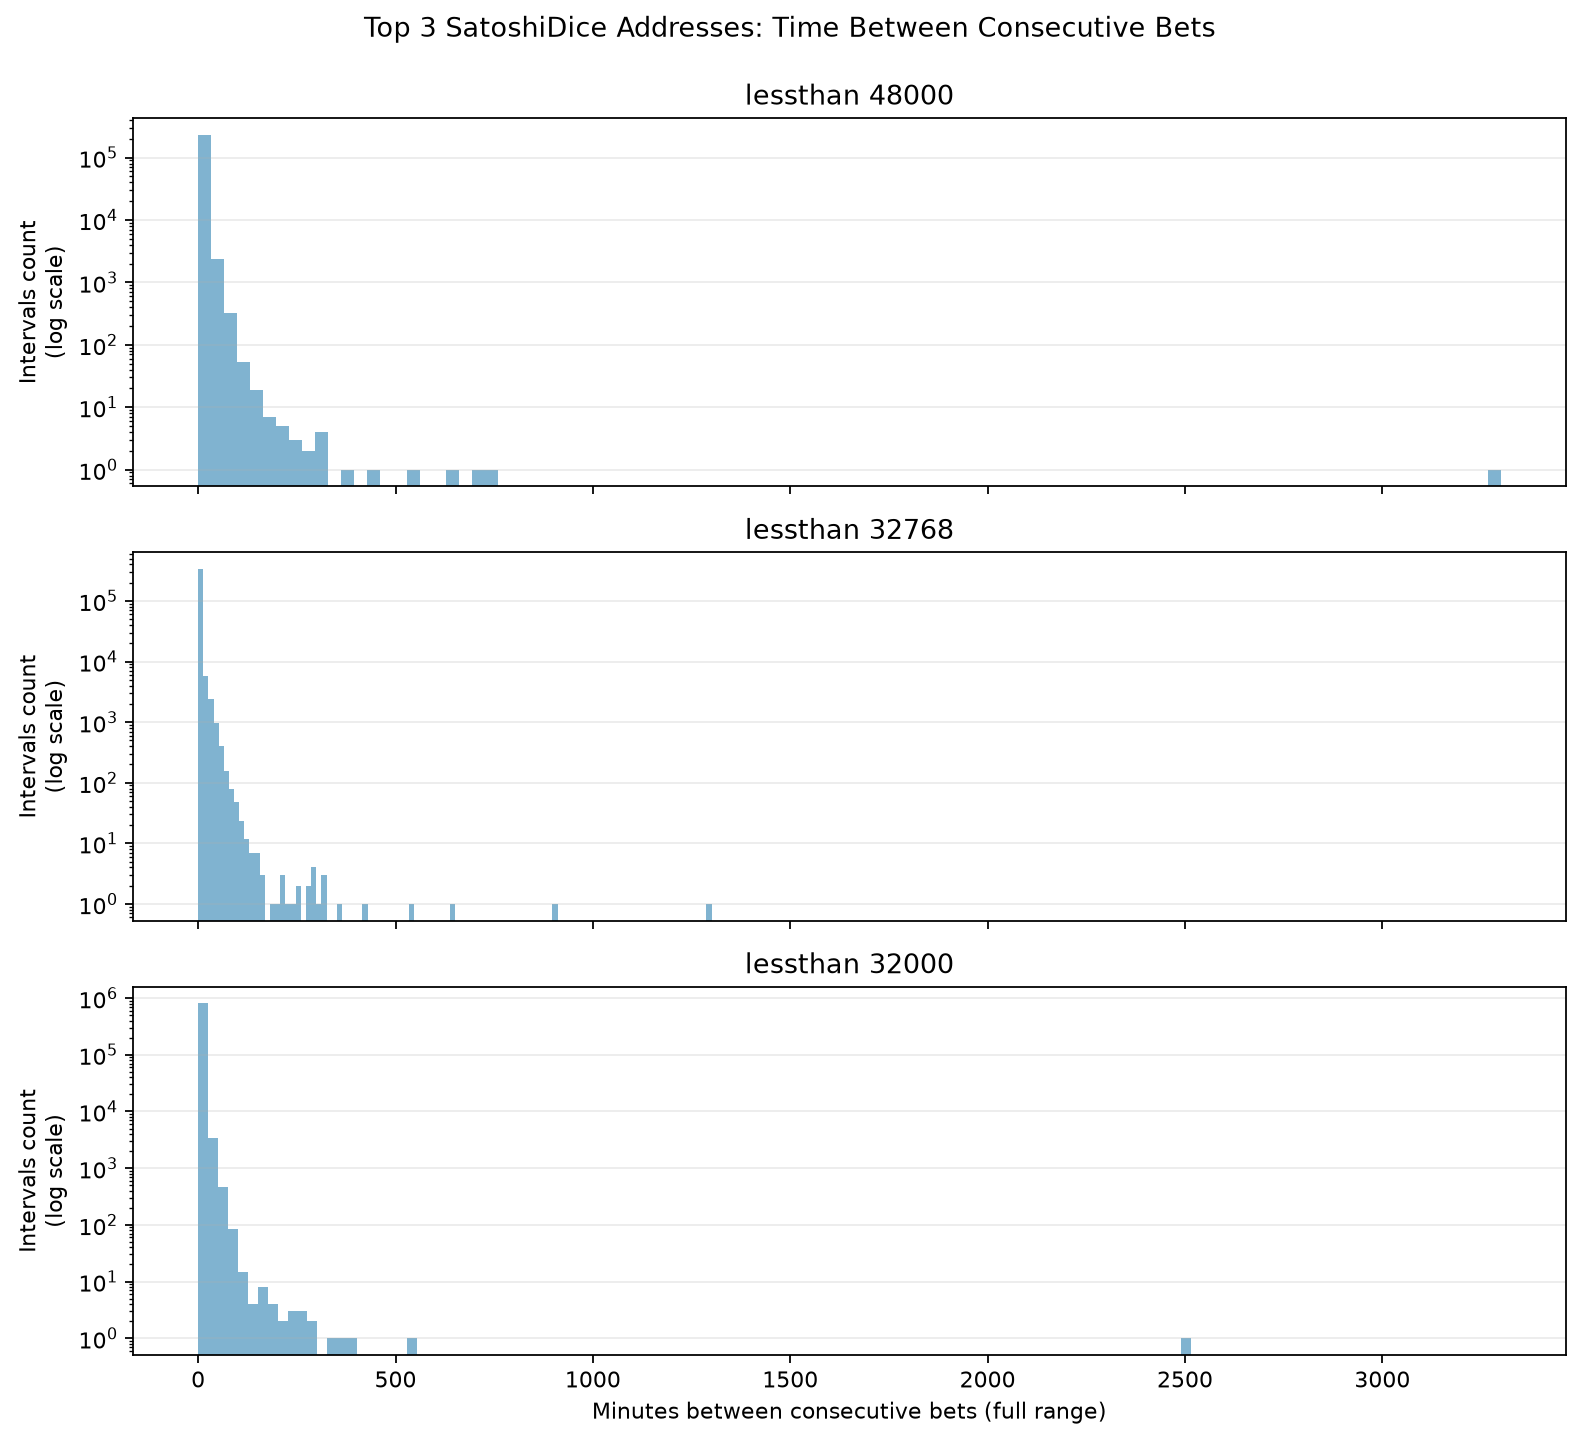

In [53]:
display(Image(FIGURES_DIR / "top3_bet_intervals_time.png"))

La mediana degli intervalli è `0` per i top address. Questo significa che molte bet consecutive hanno lo stesso timestamp, compatibilmente con burst di transazioni incluse nello stesso blocco o in blocchi molto vicini.

Il grafico mostra anche gli intervalli più lunghi, che rappresentano pause o cambi di intensità nell'attività di betting.

## 5. Analisi delle sequenze di simple bet

In questa sezione analizziamo le catene di simple bet associate all'indirizzo SatoshiDice più popolare. Una simple bet è una transazione con un solo input e due output: un output verso SatoshiDice e un output di resto, cioè il change.

Questa restrizione rende le catene più semplici da interpretare, perché il change di una bet può essere seguito direttamente quando viene riutilizzato come input della bet successiva.

### 5.1 Definizione di simple bet

Una transazione viene considerata simple bet se soddisfa queste condizioni:

- ha esattamente un input;
- ha esattamente due output;
- ha un solo output verso l'indirizzo SatoshiDice selezionato;
- ha un solo output di change.

L'indirizzo SatoshiDice analizzato è quello più popolare per numero di bet, cioè `lessthan 32000`.

Idea centrale del filtro:

```python
simple_tx_ids = tx_counts.loc[
    (tx_counts["selectedSatoshiOutputCount"] == 1)
    & (tx_counts["totalSatoshiOutputCount"] == 1)
    & (tx_counts["inputCount"] == 1)
    & (tx_counts["outputCount"] == 2),
    "txId",
]
```

### 5.2 Costruzione del grafo

Le simple bet vengono rappresentate come un grafo diretto. Ogni nodo è una transazione di simple bet, mentre un arco collega due bet se il change output della prima viene speso come input nella seconda.

```text
source change output → target input
```

```python
graph = nx.DiGraph()
graph.add_nodes_from(simple_bets["txId"])
graph.add_edges_from(
    edges[["sourceTxId", "targetTxId"]].itertuples(index=False, name=None)
)
```

### 5.3 Risultati sulle catene

Dopo aver costruito gli archi tra simple bet, le catene vengono estratte seguendo i collegamenti `sourceTxId → targetTxId`. Per ogni catena vengono calcolate lunghezza, transazione iniziale, transazione finale e durata temporale.

In [70]:
simple_chain_summary = pd.read_csv(PROCESSED_DIR / "simple_bet_chain_summary.csv")
simple_chain_summary

,simple_bets,simple_bet_edges,chains,isolated_simple_bets,max_chain_length,mean_chain_length,median_chain_length,p95_chain_length,p99_chain_length
0,526834,311847,214987,130859,717,2.450539,1.0,7.0,20.0


In [71]:
top_chains = pd.read_csv(PROCESSED_DIR / "simple_bet_chains.csv")
top_chains.head(10)

,chainId,chainLength,startTxId,endTxId,startTimestamp,endTimestamp,durationSeconds
0,29215,717,3817660,3834923,1339084266,1339126400,42134
1,31516,442,3855077,3900773,1339201696,1339318358,116662
2,27372,352,3790512,3802058,1339008282,1339040326,32044
3,21971,293,3707250,3713239,1338803546,1338812155,8609
4,12065,273,3419036,3467481,1337861529,1338021268,159739
5,32291,246,3868445,4000956,1339240360,1339577304,336944
6,159535,243,8063560,8281722,1350454695,1351026154,571459
7,27989,235,3799444,4285153,1339037301,1340082051,1044750
8,23991,233,3740182,3742539,1338864523,1338871163,6640
9,23862,229,3736704,3739223,1338855010,1338860518,5508


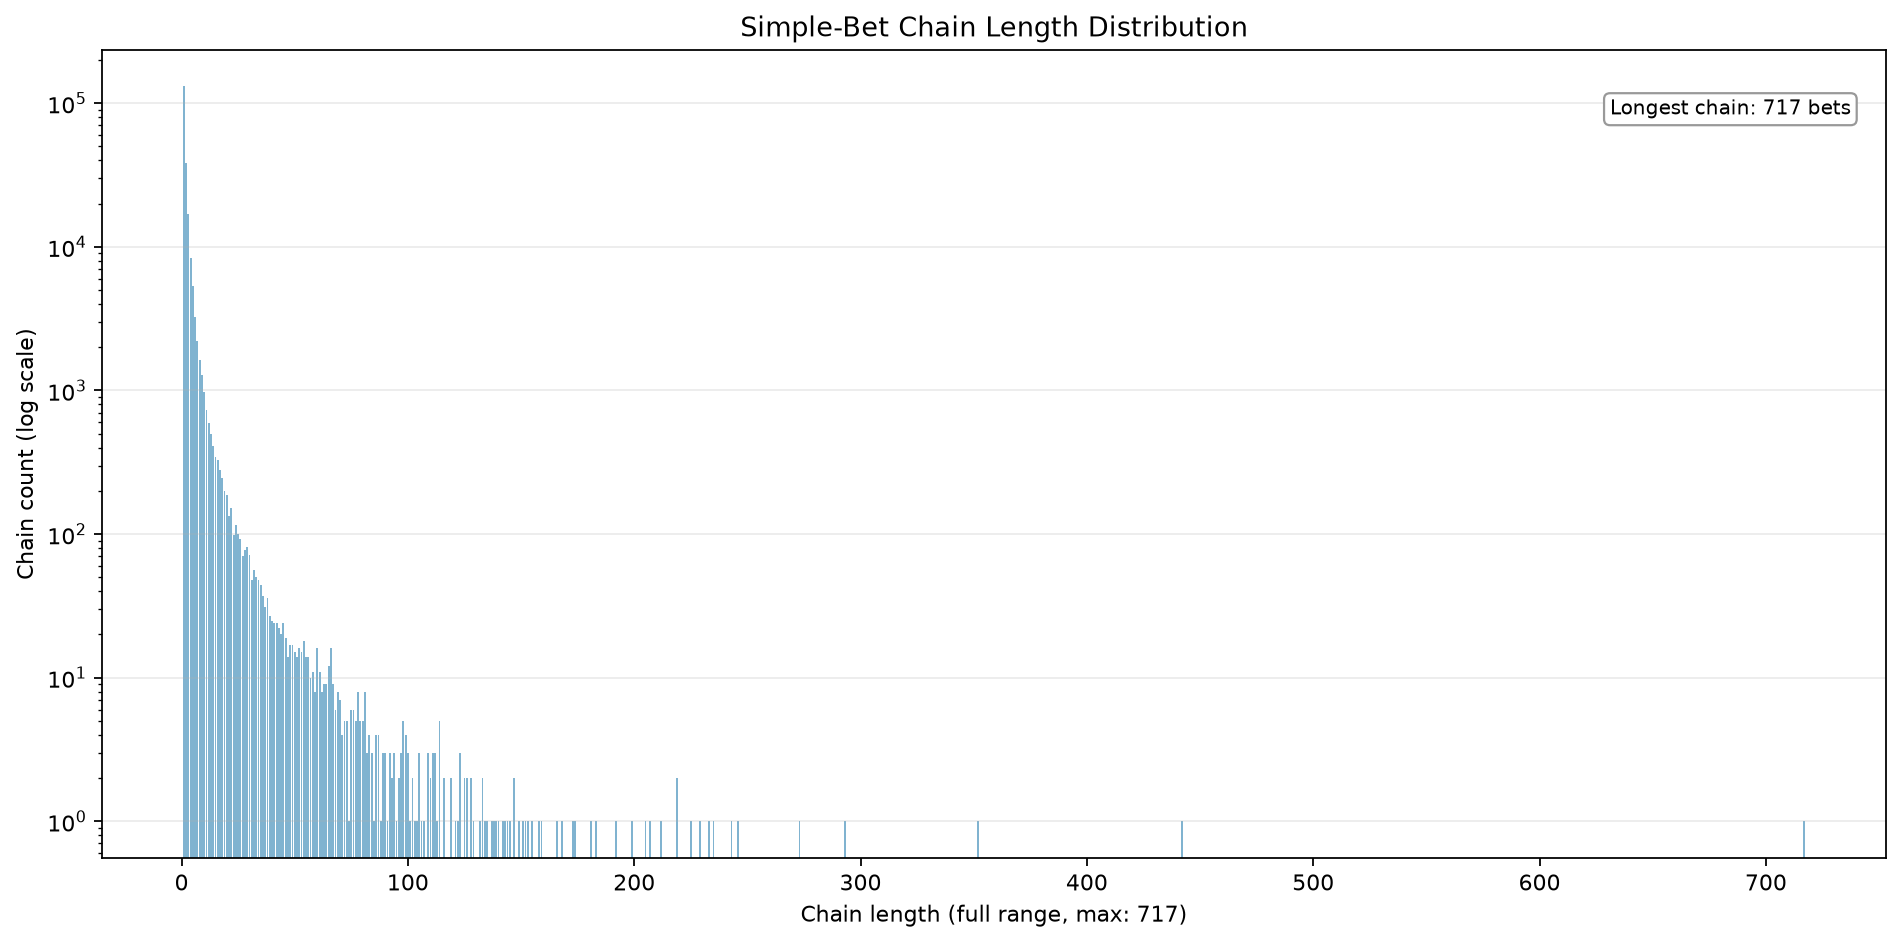

In [72]:
display(Image(FIGURES_DIR / "simple_bet_chain_lengths.png"))

La maggior parte delle catene è molto corta: la mediana della lunghezza è `1`. Tuttavia esistono anche sequenze molto lunghe, con una catena massima di `717` simple bet.

Questo suggerisce che in alcuni casi il change output venga riutilizzato ripetutamente per continuare a scommettere, creando una sequenza lineare di transazioni collegate tra loro.

## 6. Analisi WalletExplorer

Per approfondire le catene più lunghe, sono stati estratti gli indirizzi coinvolti nelle sequenze di simple bet e cercati su WalletExplorer tramite Selenium.

In questa analisi sono state considerate le `10` catene più lunghe. L'obiettivo è verificare se gli indirizzi associati a ciascuna catena appartengono allo stesso wallet cluster secondo WalletExplorer.

### 6.1 Scraping con Selenium

Lo scraping visita direttamente la pagina WalletExplorer di ogni indirizzo Bitcoin:

```text
https://www.walletexplorer.com/address/{address}
```

Dal DOM della pagina vengono estratti il wallet id, il nome del wallet e il link al wallet. È stata usata anche una cache CSV per evitare di ripetere richieste già completate.

```python
wallet_item = driver.find_element(By.CSS_SELECTOR, "span.wallet_renamer_item")
wallet_id = wallet_item.get_attribute("data-wallet-id")
wallet_name = wallet_item.find_element(By.CSS_SELECTOR, "span.wallet_name").text
```

### 6.2 Risultati WalletExplorer

La tabella seguente riassume, per ogni catena, quanti indirizzi sono stati risolti da WalletExplorer, quanti wallet distinti sono presenti e quanto pesa il wallet dominante.

In [73]:
wallet_summary = pd.read_csv(PROCESSED_DIR / "top_chain_wallet_summary.csv")
wallet_summary

,chainRank,chainId,chainLength,addresses,resolvedAddresses,unresolvedAddresses,distinctWallets,dominantWalletId,dominantWalletName,dominantWalletAddressCount,dominantWalletShare,conclusion
0,1,29215,717,718,718,0,76,0025d633f88ba307,[0025d633f8],359,0.500000,multiple_wallets
1,2,31516,442,443,443,0,2,00002c4379b1827f,[00002c4379],442,0.997743,mostly_single_wallet
2,3,27372,352,353,353,0,5,0025d633f88ba307,[0025d633f8],279,0.790368,multiple_wallets
3,4,21971,293,294,294,0,5,000f35cb33c4d172,[000f35cb33],222,0.755102,multiple_wallets
4,5,12065,273,274,274,0,2,000305c34ca27efe,[000305c34c],273,0.996350,mostly_single_wallet
5,6,32291,246,247,247,0,21,001b861dc58d5ac3,[001b861dc5],133,0.538462,multiple_wallets
6,7,159535,243,244,244,0,25,004bf37491a806d0,[004bf37491],175,0.717213,multiple_wallets
7,8,27989,235,236,236,0,11,0005f727dbee0bf6,[0005f727db],208,0.881356,multiple_wallets
8,9,23991,233,234,234,0,3,0012ea9acfdf3b20,[0012ea9acf],219,0.935897,mostly_single_wallet
9,10,23862,229,230,230,0,36,0012ea9acfdf3b20,[0012ea9acf],181,0.786957,multiple_wallets


In [74]:
wallet_summary[[
    "chainRank",
    "chainLength",
    "addresses",
    "resolvedAddresses",
    "distinctWallets",
    "dominantWalletAddressCount",
    "dominantWalletShare",
    "conclusion",
]].sort_values("dominantWalletShare", ascending=True)

,chainRank,chainLength,addresses,resolvedAddresses,distinctWallets,dominantWalletAddressCount,dominantWalletShare,conclusion
0,1,717,718,718,76,359,0.500000,multiple_wallets
5,6,246,247,247,21,133,0.538462,multiple_wallets
6,7,243,244,244,25,175,0.717213,multiple_wallets
3,4,293,294,294,5,222,0.755102,multiple_wallets
9,10,229,230,230,36,181,0.786957,multiple_wallets
2,3,352,353,353,5,279,0.790368,multiple_wallets
7,8,235,236,236,11,208,0.881356,multiple_wallets
8,9,233,234,234,3,219,0.935897,mostly_single_wallet
4,5,273,274,274,2,273,0.996350,mostly_single_wallet
1,2,442,443,443,2,442,0.997743,mostly_single_wallet


Tutti gli indirizzi analizzati sono stati risolti da WalletExplorer. Alcune catene risultano quasi completamente associate a un unico wallet dominante, mentre altre sono distribuite su molti wallet cluster.

Le chain rank `2`, `5` e `9` sono classificate come `mostly_single_wallet`, perché il wallet dominante copre più del 90% degli indirizzi. Le altre catene mostrano invece una frammentazione più evidente.

### 6.3 Interpretazione

Se una catena è associata a un solo wallet cluster, questo rafforza l'ipotesi di controllo comune degli indirizzi. Tuttavia, se WalletExplorer separa alcuni indirizzi in cluster diversi, non significa automaticamente che appartengano a persone diverse.

Per esempio, nelle chain rank `2` e `5` ci sono due wallet distinti, ma il secondo wallet contiene un solo indirizzo. In questi casi la struttura UTXO della chain resta compatibile con un singolo soggetto operativo, anche se WalletExplorer non clusterizza tutti gli indirizzi insieme.

Il mancato clustering da parte di WalletExplorer indica solo che le sue euristiche non hanno trovato evidenza sufficiente per unire quegli indirizzi.

## 7. Conclusioni

L'analisi mostra che SatoshiDice ha generato un numero elevato di transazioni identificabili sulla blockchain Bitcoin. L'attività è concentrata su pochi indirizzi principali e i payout vengono generalmente matchati rapidamente.

Le analisi sui top address mostrano attività concentrata in burst temporali e una correlazione debole tra fee e importo della bet. Questo è coerente con il fatto che la fee dipende dal funzionamento della rete Bitcoin e non dalla logica del gioco.

Le simple-bet chains evidenziano sequenze di gioco ripetute, in alcuni casi molto lunghe. L'analisi WalletExplorer rafforza l'ipotesi che alcune catene siano riconducibili a un singolo wallet operativo, mentre altre risultano più frammentate.

## 8. Limiti dell'analisi

I risultati non devono essere interpretati come prova definitiva dell'identità degli utenti. La blockchain permette di osservare transazioni, output e input, ma l'associazione tra indirizzi e persone rimane euristica.

WalletExplorer fornisce un clustering utile, ma non infallibile: indirizzi nello stesso wallet cluster possono essere controllati dallo stesso soggetto operativo, ma wallet cluster distinti non implicano necessariamente persone diverse.